## Import Libraries

In [1]:
import pandas as pd
import scanpy as sc
import anndata as ad
import matplotlib.pyplot as plt
import seaborn as sns



## Load Data


In [2]:
ctap_df = pd.read_csv("/tudelft.net/staff-umbrella/CSE30002526LIVI/AMP/raw_data/Zhang2023/Metadata/CTAP_donor_mapping.csv")
metadata_df = pd.read_csv("/tudelft.net/staff-umbrella/CSE30002526LIVI/AMP/raw_data/Zhang2023/Metadata/metadata_clin_donor_singlecell.csv")
d_embeddings_df = pd.read_csv("/tudelft.net/staff-umbrella/CSE30002526LIVI/LIVI/inference_0204/inference_0204_D_embedding.tsv", sep = '\t')

merged1_df = pd.merge(ctap_df, metadata_df)
merged2_df = pd.merge(merged1_df, d_embeddings_df, left_on='mRNA_run', right_on='individual')

print(f"ctap shape: {ctap_df.shape}")
print(f"metadata shape: {metadata_df.shape}")
print(f"d_embeddings shape: {d_embeddings_df.shape}")
print(f"merged1 shape: {merged1_df.shape}")
print(f"merged2 shape: {merged2_df.shape}")

ctap shape: (70, 3)
metadata shape: (85, 21)
d_embeddings shape: (82, 701)
merged1 shape: (70, 23)
merged2 shape: (70, 724)


## Exploratory Plots

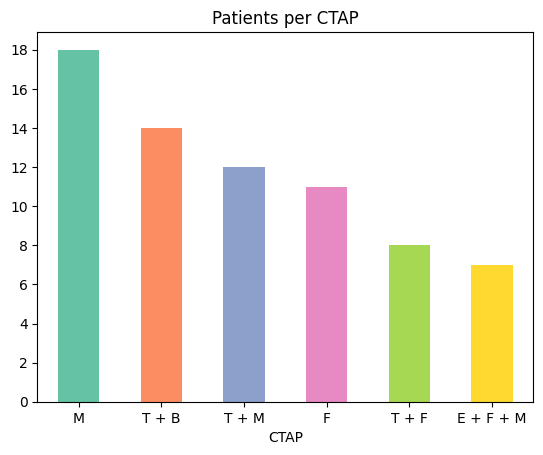

In [3]:

from matplotlib.ticker import MaxNLocator

#plot the number of patients per CTAP
ctaps = merged2_df['CTAP'].value_counts().plot(
    kind = 'bar', 
    title= "Patients per CTAP",
    color = sns.color_palette("Set2")
    )

ctaps.yaxis.set_major_locator(MaxNLocator(integer = True))
plt.xticks(rotation = 0)
plt.show()

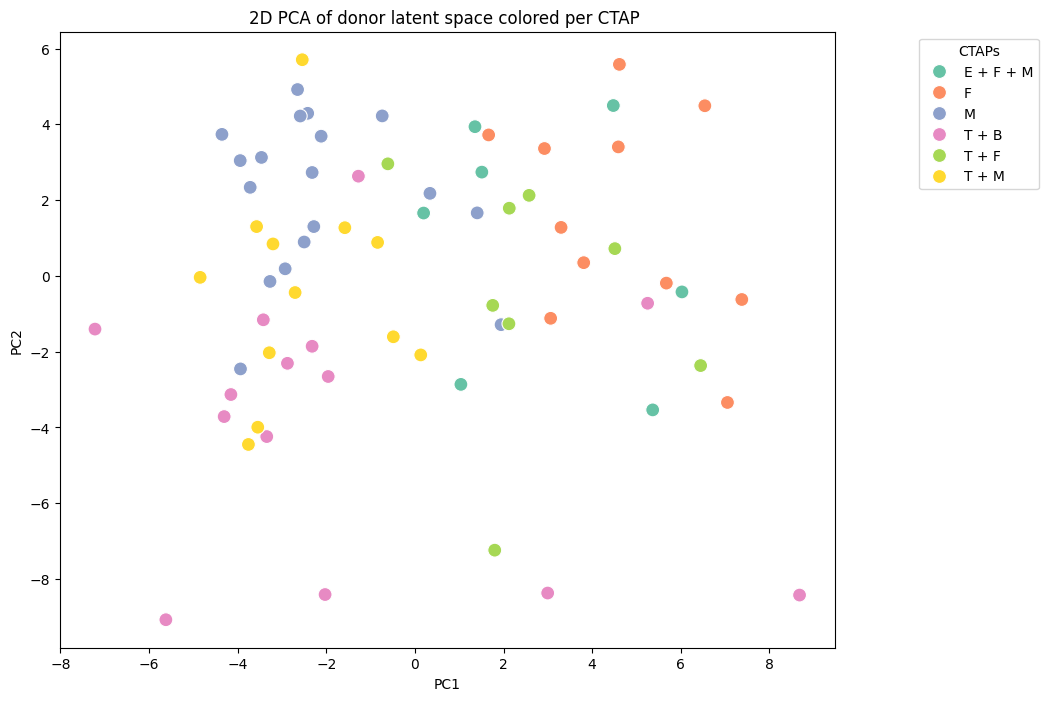

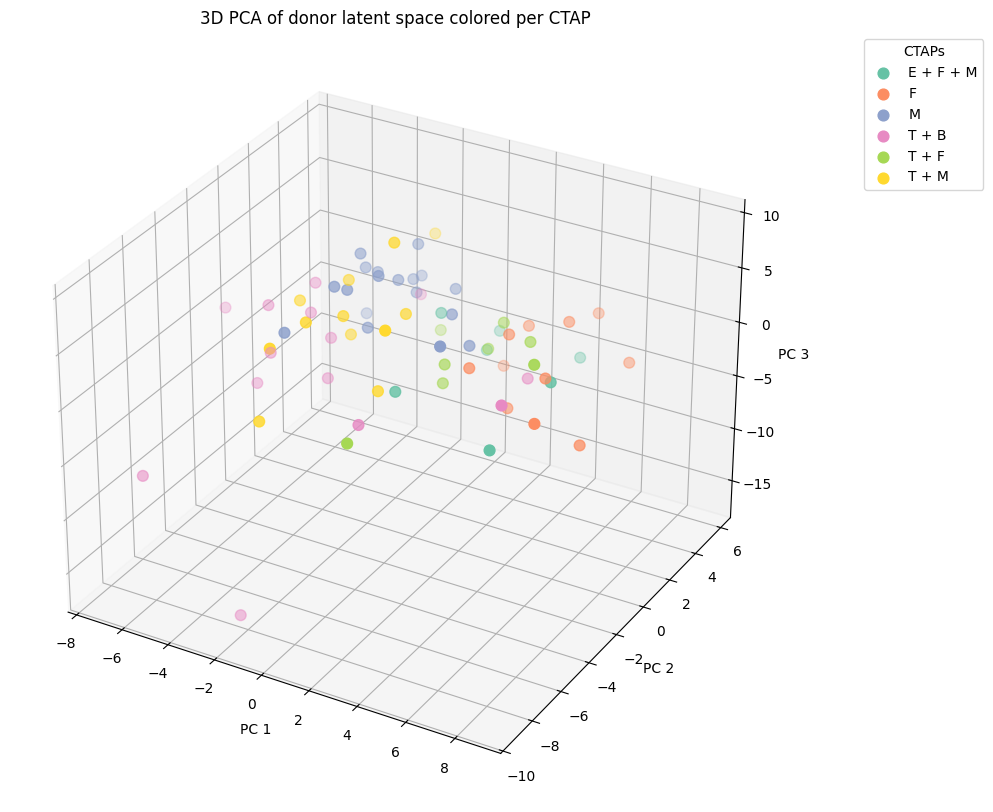

In [4]:
from sklearn.decomposition import PCA

#create a PCA of the latent space (colored per CTAP)
latent_factors = merged2_df.filter(like = 'D_Factor')
pca = PCA(n_components = 3)
pca_result = pca.fit_transform(latent_factors)

#store the dimensions in the merged dataframe so we can plot them
merged2_df['PC1'] = pca_result[:, 0]
merged2_df['PC2'] = pca_result[:, 1]
merged2_df['PC3'] = pca_result[:, 2]

#2d plot
plt.figure(figsize = (10, 8))

sns.scatterplot(
    data = merged2_df,
    x = 'PC1',
    y = 'PC2',
    hue = 'CTAP',
    palette = 'Set2',
    s = 100
)
plt.title("2D PCA of donor latent space colored per CTAP ")
plt.legend(bbox_to_anchor = (1.10, 1), loc = 'upper left', title = 'CTAPs')
plt.show()

#3d plot
fig = plt.figure(figsize = (12, 10))
plot = fig.add_subplot(111, projection = '3d')

colors = sns.color_palette("Set2", len(merged2_df['CTAP'].unique()))
map_colors = dict(zip(merged2_df['CTAP'].unique(), colors))

for ctap in merged2_df['CTAP'].unique():
    subset = merged2_df[merged2_df['CTAP'] == ctap]
    plot.scatter(
        subset['PC1'], 
        subset['PC2'], 
        subset['PC3'],
        label = ctap,
        color = map_colors[ctap],
        s = 60
    )

plot.set_xlabel('PC 1')
plot.set_ylabel('PC 2')
plot.set_zlabel('PC 3')
plt.title('3D PCA of donor latent space colored per CTAP')
plot.legend(bbox_to_anchor = (1.1, 1), loc = 'upper left', title = 'CTAPs')
plt.show()

In [5]:
import umap

#create umap of the latent space (colored per CTAP)

reducer = umap.UMAP(n_components = 2, n_neighbors= 5, min_dist = 0.01,random_state= 42)
umap_result = reducer.fit_transform(latent_factors)
print(umap_result.shape)
#store the dimensions in the merged dataframe so we can plot them
merged2_df['UMAP_1'] = umap_result[:, 0] 
merged2_df['UMAP_2'] = umap_result[:, 1]

plt.figure(figsize = (12, 8))
sns.scatterplot(
    data = merged2_df,
    x = 'UMAP_1',
    y = 'UMAP_2',
    hue = 'CTAP',
    palette = 'Set2',
    s = 100

)

plt.title("UMAP of the latent space (colored per CTAP)")
plt.legend(bbox_to_anchor = (1.10, 1), loc = 'upper right', title = 'CTAPs')
plt.show()



Exception ignored on calling ctypes callback function: <function ExecutionEngine._raw_object_cache_notify at 0x7fc564a1bc40>
Traceback (most recent call last):
  File "/tudelft.net/staff-umbrella/SPIDERR/CSE3000_2026_RP_LIVI/envs/LIVIenv/lib/python3.11/site-packages/llvmlite/binding/executionengine.py", line 178, in _raw_object_cache_notify
    def _raw_object_cache_notify(self, data):

KeyboardInterrupt: 


## Save merged2 dataframe

In [5]:
merged2_df.to_pickle("merged2_df.pkl")
print("merged2 saved")

merged2 saved
